In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
# import mlflow
# import mlflow.sklearn
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import TargetEncoder
from datetime import date, timedelta
# from google.oauth2 import service_account
# from google.cloud import bigquery
import re
import os
import sys

In [2]:
###

In [3]:
# import pandas as pd
# from sklearn.model_selection import train_test_split
# import os

# # 1. Define the file path
# file_path = r"data\raw\Hospital_Inpatient_Discharges_(SPARCS_De-Identified)__2022_20260509.csv"

# # 2. Load the dataset
# print(f"Loading data from {file_path}...")
# df = pd.read_csv(file_path)
# df.drop(columns=['Permanent Facility Id', 'Operating Certificate Number', 'CCSR Diagnosis Code', 'CCSR Procedure Code', 'APR DRG Code', 'APR MDC Code','APR Severity of Illness Code', 'Discharge Year', 'Zip Code - 3 digits', 'Payment Typology 1', 'Payment Typology 2', 'Payment Typology 3'], inplace=True)
# numerical = ['Total Charges','Total Costs','Length of Stay','Birth Weight']
# df['Birth Weight'] = df['Birth Weight'].apply(lambda x: -1 if x == "UNKN" else x)
# df['Length of Stay'] = df['Length of Stay'].apply(lambda x: 120 if x == "120 +" else x)
# for i in numerical:
#     df[i] = pd.to_numeric(df[i].astype(str).str.replace(',', ''), errors='coerce')
# # 3. Perform the 80% Train / 20% Test split
# # random_state ensures you get the exact same split every time you run this script
# train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

# # 4. Define where to save the split datasets
# output_dir = r"data\processed"
# os.makedirs(output_dir, exist_ok=True) # Creates the directory if it doesn't exist

# TRAIN_FILE = os.path.join(output_dir, "train_data.csv")
# TEST_FILE = os.path.join(output_dir, "test_data.csv")

# # 5. Save the resulting datasets back to CSV
# train_df.to_csv(TRAIN_FILE, index=False)
# test_df.to_csv(TEST_FILE, index=False)

# # 6. Print the summary
# print("\nSplit successful!")
# print(f"Original dataset shape: {df.shape}")
# print(f"Train dataset shape (80%): {train_df.shape}")
# print(f"Test dataset shape (20%): {test_df.shape}")
# print(f"\nSaved training data to: {TRAIN_FILE}")
# print(f"Saved testing data to: {TEST_FILE}")

In [4]:
# def analyze_dataframe(df):
#     """
#     Analyzes a DataFrame to provide cardinality, null counts, and top 20 value distribution.
    
#     Args:
#         df (pd.DataFrame): The dataframe to analyze.
        
#     Returns:
#         pd.DataFrame: A summary dataframe with analysis results.
#     """
#     analysis_list = []
    
#     for col in df.columns:
#         # --- Basic Metrics ---
#         dtype = df[col].dtype
#         n_total = len(df)
#         n_null = df[col].isnull().sum()
#         pct_null = (n_null / n_total) * 100
#         n_unique = df[col].nunique()
        
#         # --- Top 20 Values & Others ---
#         # value_counts(dropna=False) ensures we see NaNs if they are frequent
#         val_counts = df[col].value_counts(dropna=False)
#         top_20 = val_counts.head(20)
        
#         # Format top 20 as a readable string
#         top_values_list = []
#         for val, count in top_20.items():
#             # Formatting value to string to avoid display issues
#             top_values_list.append(f"{str(val)[:20]}: {count:,}") 
            
#         # Handle 'Others' count
#         if len(val_counts) > 20:
#             others_count = val_counts.iloc[20:].sum()
#             top_values_list.append(f"Others: {others_count:,}")
        
#         # Join into a single string for the cell
#         distribution_str = " | ".join(top_values_list)
        
#         # --- Numeric Stats (only for numeric columns) ---
#         mean_val = np.nan
#         min_val = np.nan
#         max_val = np.nan
        
#         if pd.api.types.is_numeric_dtype(df[col]):
#             mean_val = df[col].mean()
#             min_val = df[col].min()
#             max_val = df[col].max()
            
#         # --- Compile Result ---
#         analysis_list.append({
#             'Column': col,
#             'Type': dtype,
#             'Unique (Cardinality)': n_unique,
#             'Null Count': n_null,
#             'Null %': round(pct_null, 2),
#             'Min': min_val if not pd.isna(min_val) else '-',
#             'Max': max_val if not pd.isna(max_val) else '-',
#             'Mean': round(mean_val, 2) if not pd.isna(mean_val) else '-',
#             'Top Values Distribution': distribution_str
#         })
        
#     return pd.DataFrame(analysis_list)

# analyze_dataframe(df)

In [5]:
output_dir = r"data\processed"
TRAIN_FILE = os.path.join(output_dir, "train_data.csv")
TEST_FILE = os.path.join(output_dir, "test_data.csv")
df=pd.read_csv(TRAIN_FILE)


In [6]:
df.columns

Index(['Hospital Service Area', 'Hospital County', 'Facility Name',
       'Age Group', 'Gender', 'Race', 'Ethnicity', 'Length of Stay',
       'Type of Admission', 'Patient Disposition',
       'CCSR Diagnosis Description', 'CCSR Procedure Description',
       'APR DRG Description', 'APR MDC Description',
       'APR Severity of Illness Description', 'APR Risk of Mortality',
       'APR Medical Surgical Description', 'Birth Weight',
       'Emergency Department Indicator', 'Total Charges', 'Total Costs'],
      dtype='str')

In [7]:
keep_columns=['Hospital Service Area', 'Hospital County', 'Facility Name',
       'Age Group', 'Gender', 'Race', 'Ethnicity', 'Length of Stay',
       'Type of Admission', 'Patient Disposition',
       'CCSR Diagnosis Description', 'CCSR Procedure Description',
       'APR DRG Description', 'APR MDC Description',
       'APR Severity of Illness Description', 'APR Risk of Mortality',
       'APR Medical Surgical Description', 'Birth Weight',
       'Emergency Department Indicator', 'Total Charges', 'Total Costs']

df=df[keep_columns]
print(df.shape)
df = df.dropna(subset=['Total Charges', 'Total Costs'])
print(df.shape)
# df=df[df["initail_claim_approved_amount"]>0]
# print(df.shape)

(1682746, 21)
(1682746, 21)


In [8]:
df.columns

Index(['Hospital Service Area', 'Hospital County', 'Facility Name',
       'Age Group', 'Gender', 'Race', 'Ethnicity', 'Length of Stay',
       'Type of Admission', 'Patient Disposition',
       'CCSR Diagnosis Description', 'CCSR Procedure Description',
       'APR DRG Description', 'APR MDC Description',
       'APR Severity of Illness Description', 'APR Risk of Mortality',
       'APR Medical Surgical Description', 'Birth Weight',
       'Emergency Department Indicator', 'Total Charges', 'Total Costs'],
      dtype='str')

In [9]:
# df['TEMP_HOSPITAL_MARGIN'] = (df['Total Charges'] - df['Total Costs']) / df['Total Charges']
# df['TEMP_HOSPITAL_MARGIN'] = df['TEMP_HOSPITAL_MARGIN'].fillna(0).clip(0, 1)


In [10]:
from sklearn.base import BaseEstimator, TransformerMixin


class AutomatedFeatureEngineer(BaseEstimator, TransformerMixin):
    def __init__(self):
        # 1. Define Column Groups
        self.te_charge_cols = ['CCSR Diagnosis Description', 'CCSR Procedure Description', 'APR DRG Description']
        self.te_days_in_hosp_cols = ['CCSR Diagnosis Description', 'CCSR Procedure Description', 'APR DRG Description']
        
        self.ordinal_cols = [
            'Hospital Service Area', 'Hospital County', 'Facility Name',
            'Age Group', 'Gender', 'Race', 'Ethnicity', 
            'Type of Admission', 'Patient Disposition', 
            'APR MDC Description', 'APR Severity of Illness Description', 
            'APR Risk of Mortality', 'APR Medical Surgical Description', 
            'Emergency Department Indicator'
        ]
        
        self.numerical_cols = []
        
        # 2. Initialize Encoders
        self.ord_enc = OrdinalEncoder(
            handle_unknown='use_encoded_value', unknown_value=-1, 
            encoded_missing_value=-1, max_categories=250
        )
        self.charge_enc = TargetEncoder(smooth=50.0, target_type='continuous')
        self.dih_enc = TargetEncoder(smooth=20.0, target_type='continuous')

    def fit(self, X, y=None):
        """Learns the encodings from the Training Data (used during inference setup)"""
        self.ord_enc.fit(X[self.ordinal_cols].astype(str))
        
        # Fit Charge Encoder using the pipeline's 'y' variable
        if len(self.te_charge_cols) > 0 and y is not None:
            self.charge_enc.fit(X[self.te_charge_cols], y)
            
        # Fit Days in Hospital using 'Length of Stay' from X
        if len(self.te_days_in_hosp_cols) > 0 and 'Length of Stay' in X.columns:
            self.dih_enc.fit(X[self.te_days_in_hosp_cols], X['Length of Stay'])
                
        return self

    def fit_transform(self, X, y=None):
        """Overrides default to force TargetEncoder cross-fitting during training"""
        X_out = X.copy()
        
        # A. Apply Ordinal
        X_out[self.ordinal_cols] = self.ord_enc.fit_transform(X_out[self.ordinal_cols].astype(str))
        
        # B. Apply Charge Encoding WITH Cross-Fitting (Uses 'y')
        if len(self.te_charge_cols) > 0 and y is not None:
            charge_trans_arr = self.charge_enc.fit_transform(X_out[self.te_charge_cols], y)
            charge_trans = pd.DataFrame(
                charge_trans_arr, 
                columns=[c + '_MEDIAN_COST' for c in self.te_charge_cols], 
                index=X.index
            )
        else:
            charge_trans = pd.DataFrame(index=X.index)
            
        # C. Apply Days in Hospital Encoding WITH Cross-Fitting (Uses 'Length of Stay')
        if len(self.te_days_in_hosp_cols) > 0 and 'Length of Stay' in X_out.columns:
            dih_trans_arr = self.dih_enc.fit_transform(X_out[self.te_days_in_hosp_cols], X_out['Length of Stay'])
            dih_trans = pd.DataFrame(
                dih_trans_arr, 
                columns=[c + '_DIH' for c in self.te_days_in_hosp_cols], 
                index=X.index
            )
        else:
            dih_trans = pd.DataFrame(index=X.index)

        # D. Combine & Return
        X_final = pd.concat([
            X_out[self.numerical_cols],
            X_out[self.ordinal_cols],
            charge_trans,
            dih_trans
        ], axis=1)
        
        return X_final.fillna(0)

    def transform(self, X):
        """Applies the learnt encodings to new data (Validation/Test)"""
        X_out = X.copy()
        
        X_out[self.ordinal_cols] = self.ord_enc.transform(X[self.ordinal_cols].astype(str))
        
        if len(self.te_charge_cols) > 0:
            charge_trans_arr = self.charge_enc.transform(X[self.te_charge_cols])
            charge_trans = pd.DataFrame(
                charge_trans_arr, 
                columns=[c + '_MEDIAN_COST' for c in self.te_charge_cols], 
                index=X.index
            )
        else:
            charge_trans = pd.DataFrame(index=X.index) 
        
        if len(self.te_days_in_hosp_cols) > 0:
            dih_trans_arr = self.dih_enc.transform(X[self.te_days_in_hosp_cols])
            dih_trans = pd.DataFrame(
                dih_trans_arr, 
                columns=[c + '_DIH' for c in self.te_days_in_hosp_cols], 
                index=X.index
            )
        else:
            dih_trans = pd.DataFrame(index=X.index) 
        
        X_final = pd.concat([
            X_out[self.numerical_cols],
            X_out[self.ordinal_cols],
            charge_trans,
            dih_trans
        ], axis=1)
        
        return X_final.fillna(0)

In [11]:
# 2. Split Data
X = df.drop(columns=[]) 
y = df['Total Charges']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [12]:
# 3. Define Pipeline
# The pipeline now contains the Feature Engineering logic INSIDE it.
pipeline = Pipeline([
    ('feature_engineer', AutomatedFeatureEngineer()),
    ('regressor', HistGradientBoostingRegressor(
        learning_rate=0.1,
        max_iter=100,
        max_leaf_nodes=31,
        random_state=42
    ))
])

In [13]:
# 4. Run MLflow

print("Starting Training...")
    
# Fit the pipeline on RAW data
# The pipeline will internally calculate Median Costs and Rejection Rates
pipeline.fit(X_train, y_train)
    
print("Training Complete. Evaluating...")
    
# Cross Validation
cv_scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='neg_mean_squared_error')
rmse_scores = np.sqrt(-cv_scores)
    
print(f"CV RMSE: {rmse_scores.mean():.2f}")

    
# Final Test Score
y_pred = pipeline.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
test_rmse = np.sqrt(mse)
    
print(f"Test RMSE: {test_rmse:.2f}")
   


Starting Training...
Training Complete. Evaluating...
CV RMSE: 102558.86
Test RMSE: 110451.11


In [14]:
import pandas as pd
import numpy as np
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# 1. Define Helper Function FIRST
def analyze_errors(y_true, y_pred, set_name="Test"):
    """
    Calculates and prints regression performance metrics.
    """
    results = pd.DataFrame({'Actual': y_true, 'Predicted': y_pred})
    results['Error'] = results['Predicted'] - results['Actual']
    
    # Metrics
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse) 
    
    # Over/Under Stats
    over_preds = results[results['Error'] > 0]
    under_preds = results[results['Error'] < 0]
    
    # Calculations
    over_count = len(over_preds)
    over_pct = (over_count / len(results)) * 100 if len(results) > 0 else 0
    over_mae = over_preds['Error'].mean() if over_count > 0 else 0
    
    under_count = len(under_preds)
    under_pct = (under_count / len(results)) * 100 if len(results) > 0 else 0
    under_mae = abs(under_preds['Error']).mean() if under_count > 0 else 0
    
    print(f"\n" + "="*50)
    print(f"       {set_name.upper()} PERFORMANCE REPORT       ")
    print("="*50)
    print(f"Overall R-Squared: {r2:.4f}")
    print(f"Overall MAE:       Rs{mae:,.2f}")
    print(f"Overall RMSE:      Rs{rmse:,.2f}")
    print("-" * 50)
    print(f"{'Category':<20} | {'Count':<10} | {'% of Total':<10} | {'Avg Error (MAE)':<15}")
    print("-" * 50)
    print(f"{'Over-Predictions':<20} | {over_count:<10} | {over_pct:<10.1f}% | Rs{over_mae:,.2f}")
    print(f"{'Under-Predictions':<20} | {under_count:<10} | {under_pct:<10.1f}% | Rs{under_mae:,.2f}")
    print("="*50)
    
    return {'r2': r2, 'mae': mae, 'rmse': rmse}

# ==========================================================
# PART A: INTERNAL VALIDATION SET ANALYSIS
# ==========================================================
# This uses X_test/y_test from your train_test_split (the 20% holdout)
print("Running prediction on Internal Validation Set...")
y_pred_val = pipeline.predict(X_test)

analyze_errors(y_test, y_pred_val, set_name="INTERNAL VALIDATION (20% Split)")

# ==========================================================
# PART B: EXTERNAL HELD-OUT TEST SET ANALYSIS
# ==========================================================
# This uses the separate 'test.csv' file
print("\nProcessing External Held-Out Test Set...")

# 1. Load Data
df_test_raw = pd.read_csv(TEST_FILE)
df_test = df_test_raw.copy()
print(df_test.shape)
# df_test=df_test[~df_test['Pol_CorporateId'].isnull()]
# print(df_test.shape)

# Transformation logic
keep_columns_test = [i for i in keep_columns if i not in ['Length of Stay']]
df_test=df_test[keep_columns_test]
print(df_test.shape)
df_test = df_test.dropna(subset=['Total Costs', 'Total Charges'])
# df_test['CLAIM_DIFFERENCE'] = df_test['initial_claim_amount'] - df_test['initail_claim_approved_amount']
#df_test=df_test[df_test["initail_claim_approved_amount"]>0]
print(df_test.shape)

# 3. Feature Prep (Target calc required for Transformation logic)
#df_test['TEMP_REJECTION_RATIO'] = (df_test['FINAL_CLAIM_AMOUNT'] - df_test['FINAL_CLAIM_APPROVED_AMOUNT']) / df_test['FINAL_CLAIM_AMOUNT']
#df_test['TEMP_REJECTION_RATIO'] = df_test['TEMP_REJECTION_RATIO'].fillna(0).clip(0, 1)

# 4. Prepare Final X and y
# Note: CCN_NO is ID, FINAL_OOP is Target
X_test_final = df_test.drop(columns=['Total Charges'], errors='ignore')
y_test_final = df_test['Total Charges']

# 5. Predict & Evaluate
print("Generating predictions for External Test Set...")
y_pred_external = pipeline.predict(X_test_final)

analyze_errors(y_test_final, y_pred_external, set_name="EXTERNAL HELD-OUT TEST")

print("\nEvaluation Complete.")

Running prediction on Internal Validation Set...

       INTERNAL VALIDATION (20% SPLIT) PERFORMANCE REPORT       
Overall R-Squared: 0.5520
Overall MAE:       Rs35,958.68
Overall RMSE:      Rs110,451.11
--------------------------------------------------
Category             | Count      | % of Total | Avg Error (MAE)
--------------------------------------------------
Over-Predictions     | 208212     | 61.9      % | Rs28,743.57
Under-Predictions    | 128338     | 38.1      % | Rs47,664.27

Processing External Held-Out Test Set...
(420687, 21)
(420687, 20)
(420687, 20)
Generating predictions for External Test Set...

       EXTERNAL HELD-OUT TEST PERFORMANCE REPORT       
Overall R-Squared: 0.5689
Overall MAE:       Rs35,863.15
Overall RMSE:      Rs103,622.47
--------------------------------------------------
Category             | Count      | % of Total | Avg Error (MAE)
--------------------------------------------------
Over-Predictions     | 260262     | 61.9      % | Rs28,876.45
U

Calculating importance for Validation Set (Train Split)...
Calculating importance for Held-Out Test Set...


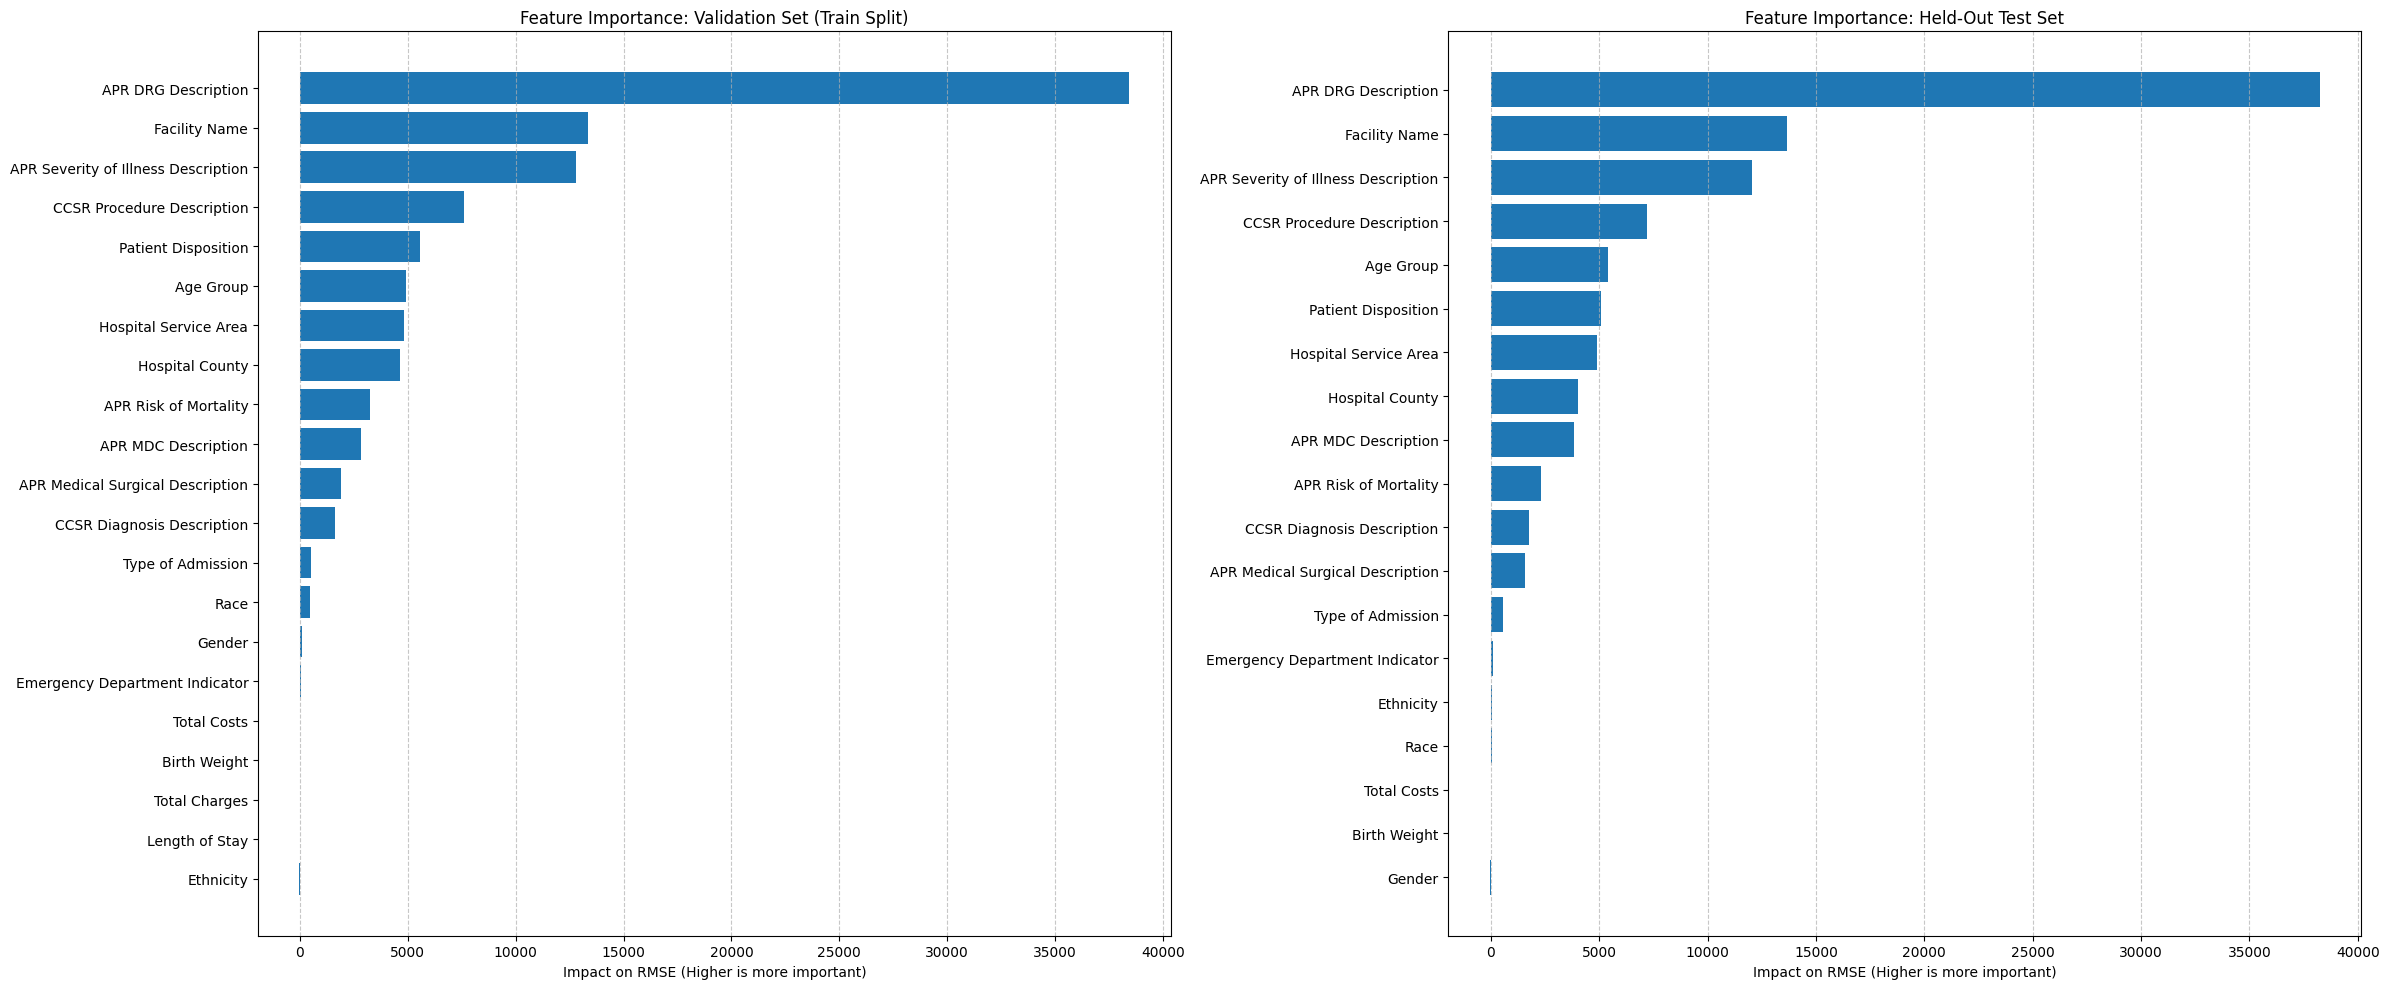

In [15]:
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt

def plot_importance(ax, model, X, y, dataset_name):
    """Helper function to calculate and plot importance on a specific ax"""
    print(f"Calculating importance for {dataset_name}...")
    result = permutation_importance(
        model, X, y, 
        n_repeats=1, 
        random_state=42,
        n_jobs=-1,
        scoring='neg_root_mean_squared_error'
    )
    sorted_idx = result.importances_mean.argsort()
    
    ax.barh(X.columns[sorted_idx], result.importances_mean[sorted_idx])
    ax.set_xlabel("Impact on RMSE (Higher is more important)")
    ax.set_title(f"Feature Importance: {dataset_name}")
    ax.grid(axis='x', linestyle='--', alpha=0.7)

# Set up the figure for side-by-side comparison
fig, axes = plt.subplots(1, 2, figsize=(24, 10))

# 1. Plot for Validation Data (Portion of Train)
#    This shows what the model prioritized during training/tuning.
plot_importance(axes[0], pipeline, X_test, y_test, "Validation Set (Train Split)")

# 2. Plot for Held-Out Test Data (External Test File)
#    This confirms if those same features are actually driving predictions 
#    in the real world, or if the model overfitted to training artifacts.
plot_importance(axes[1], pipeline, X_test_final, y_test_final, "Held-Out Test Set")

plt.tight_layout()
plt.show()

In [16]:
# =========================================================
# NEW BLOCK: SEPARATE RESIDUAL ANALYSIS (UNDER VS OVER)
# =========================================================
print("Generating Separated Residual Analysis...")

# 1. Get predictions on Training Set
y_train_pred_analysis = pipeline.predict(X_train)
residuals_train = y_train - y_train_pred_analysis

# 2. Split into Under and Over Prediction Sets
# Under-prediction: Actual > Predicted (Residual is Positive)
under_errors = residuals_train[residuals_train > 0]

# Over-prediction: Predicted > Actual (Residual is Negative)
# We take absolute value to analyze the "Magnitude" of the error
over_errors = np.abs(residuals_train[residuals_train < 0])

# 3. Define Percentiles of Interest
percentiles = [50, 66, 75, 80, 85, 90, 95, 99]

# --- Report 1: Under-Prediction Thresholds ---
print("\n" + "="*60)
print("   UNDER-PREDICTION ANALYSIS (Actual > Predicted)")
print("="*60)
print(f"{'Percentile':<15} | {'Error Magnitude':<20} | {'Interpretation'}")
print("-" * 60)

for p in percentiles:
    val = np.percentile(under_errors, p)
    print(f"{p:<15} | Rs{val:<19,.0f} | Covers {p}% of under-predictions")

print("-" * 60)
print("RECOMMENDATION: Pick the 90th or 95th percentile value.")
print("(e.g., if 95th is Rs8,000, it means 95% of under-errors are < Rs8k)")

# --- Report 2: Over-Prediction Thresholds ---
print("\n" + "="*60)
print("   OVER-PREDICTION ANALYSIS (Predicted > Actual)")
print("="*60)
print(f"{'Percentile':<15} | {'Error Magnitude':<20} | {'Interpretation'}")
print("-" * 60)

for p in percentiles:
    val = np.percentile(over_errors, p)
    print(f"{p:<15} | Rs{val:<19,.0f} | Covers {p}% of over-predictions")

print("-" * 60)
print("RECOMMENDATION: Pick the 90th or 95th percentile value.")
print("(Over-prediction errors are usually larger, so this number might be higher)")
print("="*60)

Generating Separated Residual Analysis...

   UNDER-PREDICTION ANALYSIS (Actual > Predicted)
Percentile      | Error Magnitude      | Interpretation
------------------------------------------------------------
50              | Rs14,796              | Covers 50% of under-predictions
66              | Rs28,247              | Covers 66% of under-predictions
75              | Rs42,192              | Covers 75% of under-predictions
80              | Rs54,474              | Covers 80% of under-predictions
85              | Rs72,890              | Covers 85% of under-predictions
90              | Rs103,925             | Covers 90% of under-predictions
95              | Rs176,664             | Covers 95% of under-predictions
99              | Rs497,468             | Covers 99% of under-predictions
------------------------------------------------------------
RECOMMENDATION: Pick the 90th or 95th percentile value.
(e.g., if 95th is Rs8,000, it means 95% of under-errors are < Rs8k)

   OVER-PRED

In [17]:
# =========================================================
# NEW STEP: TRAIN MODEL V2 (THE SPECIALIST) & ANALYZE DROPS
# =========================================================
print("\n" + "="*80)
print("        TRAINING REGRESSION MODEL V2 (ON CLEAN DATA)")
print("="*80)

# 1. Define Your Custom Thresholds
UNDER_LIMIT = 50000  # Remove if Actual is > 15k higher than Pred
OVER_LIMIT = 50000   # Remove if Pred is > 30k higher than Actual

# 2. Helper Function to Show Data Drop Stats
def print_drop_stats(model, X, y, name, is_training=False):
    """Calculates how many rows are 'Clean' vs 'Outlier' based on Model 1"""
    # Get Model 1 Predictions
    preds = model.predict(X)
    residuals = y - preds
    
    # Define Mask
    mask_clean = (residuals < UNDER_LIMIT) & (residuals > -OVER_LIMIT)
    
    n_total = len(X)
    n_clean = mask_clean.sum()
    n_drop = n_total - n_clean
    pct_drop = (n_drop / n_total) * 100
    
    print(f"{name} Impact:")
    print(f" - Original Size: {n_total}")
    print(f" - Clean Data:    {n_clean} (Keep {100-pct_drop:.1f}%)")
    print(f" - Outliers:      {n_drop} (Drop {pct_drop:.1f}%)")
    
    if is_training:
        return X[mask_clean].copy(), y[mask_clean].copy()
    return None, None

# 3. Apply Filtering
# --- A. Training Set (Actual Filtering) ---
X_train_clean, y_train_clean = print_drop_stats(pipeline, X_train, y_train, "TRAINING SET", is_training=True)

# --- B. Validation & Test Sets (Just for View) ---
print("-" * 40)
print_drop_stats(pipeline, X_test, y_test, "INTERNAL VALIDATION (Hypothetical)")
print_drop_stats(pipeline, X_test_final, y_test_final, "EXTERNAL TEST (Hypothetical)")
print("-" * 80)

# 4. Initialize Pipeline V2 (Clone of V1)
from sklearn.base import clone
# This creates a fresh copy of the pipeline structure.
# It is NOT fitted yet, so it has no memory of the old 'poisoned' stats.
pipeline_v2 = clone(pipeline) 

# 5. Train V2 on Clean Data
print("Training Pipeline V2 (The Specialist)...")
pipeline_v2.fit(X_train_clean, y_train_clean)
print("✅ Pipeline V2 Trained.")

# 6. Evaluate V2 Performance (On Full Sets)
#    We evaluate on the FULL sets to confirm that V2 performs well on average,
#    even though we know it will fail on the outliers (that's the Risk Classifier's job).
print("\n--- Evaluating Model V2 on Internal Validation ---")
y_pred_val_v2 = pipeline_v2.predict(X_test)
analyze_errors(y_test, y_pred_val_v2, set_name="MODEL V2 - INTERNAL VAL")

print("\n--- Evaluating Model V2 on External Test ---")
y_pred_ext_v2 = pipeline_v2.predict(X_test_final)
analyze_errors(y_test_final, y_pred_ext_v2, set_name="MODEL V2 - EXTERNAL TEST")


        TRAINING REGRESSION MODEL V2 (ON CLEAN DATA)
TRAINING SET Impact:
 - Original Size: 1346196
 - Clean Data:    1114693 (Keep 82.8%)
 - Outliers:      231503 (Drop 17.2%)
----------------------------------------
INTERNAL VALIDATION (Hypothetical) Impact:
 - Original Size: 336550
 - Clean Data:    278772 (Keep 82.8%)
 - Outliers:      57778 (Drop 17.2%)
EXTERNAL TEST (Hypothetical) Impact:
 - Original Size: 420687
 - Clean Data:    348242 (Keep 82.8%)
 - Outliers:      72445 (Drop 17.2%)
--------------------------------------------------------------------------------
Training Pipeline V2 (The Specialist)...
✅ Pipeline V2 Trained.

--- Evaluating Model V2 on Internal Validation ---

       MODEL V2 - INTERNAL VAL PERFORMANCE REPORT       
Overall R-Squared: 0.4960
Overall MAE:       Rs35,047.40
Overall RMSE:      Rs117,160.77
--------------------------------------------------
Category             | Count      | % of Total | Avg Error (MAE)
-----------------------------------------

{'r2': 0.5100719357812937,
 'mae': 34903.81421518783,
 'rmse': np.float64(110463.86937728622)}


        TRAINING DUAL RISK CLASSIFIERS
Risk Criteria 1: Underprediction >= 25000
Risk Criteria 2: Overprediction >= 35000
Generating Hybrid Features for Training...
Risk Class Balance (Under): 16.49% Risky
Risk Class Balance (Over):  9.80% Risky
Training Under-Prediction Classifier...
Training Over-Prediction Classifier...
✅ Both Hybrid Risk Classifiers Trained.

--- Risk Evaluation: INTERNAL VALIDATION ---
>>> UNDER-PREDICTION RISK REPORT:
              precision    recall  f1-score   support

           0       0.94      0.64      0.76    281073
           1       0.30      0.80      0.44     55477

    accuracy                           0.66    336550
   macro avg       0.62      0.72      0.60    336550
weighted avg       0.84      0.66      0.71    336550

>>> OVER-PREDICTION RISK REPORT:
              precision    recall  f1-score   support

           0       0.99      0.79      0.88    303748
           1       0.32      0.93      0.48     32802

    accuracy                  

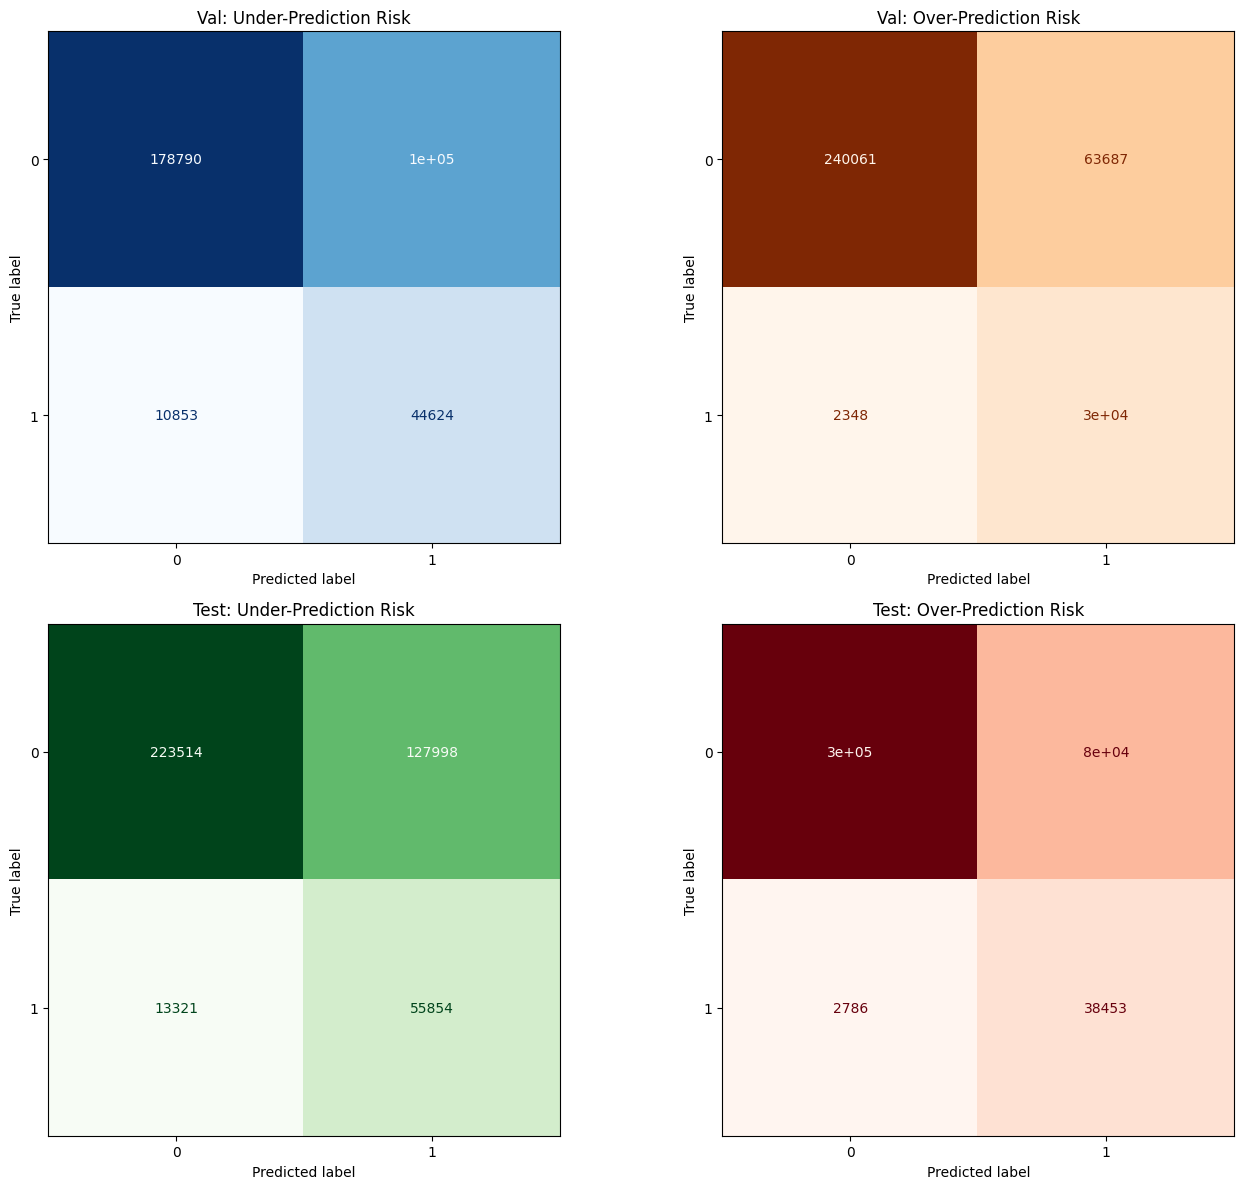

In [18]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# =========================================================
# 2. DUAL RISK CLASSIFIERS (UNDER & OVER PREDICTION)
# =========================================================
print("\n" + "="*80)
print("        TRAINING DUAL RISK CLASSIFIERS")
print("="*80)

# Define separate limits based on your new rules
RISK_UNDER_LIMIT = 25000   
RISK_OVER_LIMIT = 35000   

print(f"Risk Criteria 1: Underprediction >= {RISK_UNDER_LIMIT}")
print(f"Risk Criteria 2: Overprediction >= {RISK_OVER_LIMIT}")

def create_hybrid_features(X_raw, model_v1, model_v2):
    X_v2 = model_v2.named_steps['feature_engineer'].transform(X_raw)
    X_v1_all = model_v1.named_steps['feature_engineer'].transform(X_raw)
    
    cols_to_keep = [c for c in X_v1_all.columns if 'MEDIAN_COST' in c or 'DIH' in c]
    X_v1_subset = X_v1_all[cols_to_keep].copy()
    X_v1_subset.columns = [c + '_M1_HIST' for c in X_v1_subset.columns]
    
    preds_v1 = model_v1.predict(X_raw)
    preds_v2 = model_v2.predict(X_raw)
    
    X_hybrid = pd.concat([X_v2, X_v1_subset], axis=1)
    X_hybrid['PRED_M1_DIRTY'] = preds_v1
    X_hybrid['PRED_M2_CLEAN'] = preds_v2
    X_hybrid['PRED_DIFF'] = preds_v1 - preds_v2 
    
    return X_hybrid.fillna(0), preds_v2

print("Generating Hybrid Features for Training...")
X_train_risk_hybrid, y_train_pred_v2 = create_hybrid_features(X_train, pipeline, pipeline_v2)

# Calculate Residuals (Actual - Predicted)
residuals_v2 = y_train - y_train_pred_v2

# Create TWO distinct targets
y_train_risk_under = (residuals_v2 >= RISK_UNDER_LIMIT).astype(int)
y_train_risk_over = (residuals_v2 <= -RISK_OVER_LIMIT).astype(int)

print(f"Risk Class Balance (Under): {y_train_risk_under.mean():.2%} Risky")
print(f"Risk Class Balance (Over):  {y_train_risk_over.mean():.2%} Risky")

# Train Under-Prediction Classifier
print("Training Under-Prediction Classifier...")
risk_clf_under = HistGradientBoostingClassifier(
    learning_rate=0.05, max_iter=150, max_leaf_nodes=31,
    random_state=42, class_weight='balanced', scoring='f1'
)
risk_clf_under.fit(X_train_risk_hybrid, y_train_risk_under)

# Train Over-Prediction Classifier
print("Training Over-Prediction Classifier...")
risk_clf_over = HistGradientBoostingClassifier(
    learning_rate=0.05, max_iter=150, max_leaf_nodes=31,
    random_state=43, class_weight='balanced', scoring='f1'
)
risk_clf_over.fit(X_train_risk_hybrid, y_train_risk_over)

print("✅ Both Hybrid Risk Classifiers Trained.")

# =========================================================
# 3. EVALUATION (ON VALIDATION & TEST)
# =========================================================
def evaluate_dual_risk_models(X_raw, y_true, name):
    print(f"\n--- Risk Evaluation: {name} ---")
    
    X_hybrid, y_pred_reg_v2 = create_hybrid_features(X_raw, pipeline, pipeline_v2)
    residuals = y_true - y_pred_reg_v2
    
    # Ground Truths
    y_true_under = (residuals >= RISK_UNDER_LIMIT).astype(int)
    y_true_over = (residuals <= -RISK_OVER_LIMIT).astype(int)
    
    # Predictions
    y_pred_under = risk_clf_under.predict(X_hybrid)
    y_pred_over = risk_clf_over.predict(X_hybrid)
    
    print(">>> UNDER-PREDICTION RISK REPORT:")
    print(classification_report(y_true_under, y_pred_under))
    print(">>> OVER-PREDICTION RISK REPORT:")
    print(classification_report(y_true_over, y_pred_over))
    
    return y_true_under, y_pred_under, y_true_over, y_pred_over

# Run Evaluation
val_u_true, val_u_pred, val_o_true, val_o_pred = evaluate_dual_risk_models(X_test, y_test, "INTERNAL VALIDATION")
ext_u_true, ext_u_pred, ext_o_true, ext_o_pred = evaluate_dual_risk_models(X_test_final, y_test_final, "EXTERNAL TEST")

# Plot Confusion Matrices (2x2 Grid)
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

ConfusionMatrixDisplay.from_predictions(val_u_true, val_u_pred, ax=axes[0, 0], cmap='Blues', colorbar=False)
axes[0, 0].set_title("Val: Under-Prediction Risk")

ConfusionMatrixDisplay.from_predictions(val_o_true, val_o_pred, ax=axes[0, 1], cmap='Oranges', colorbar=False)
axes[0, 1].set_title("Val: Over-Prediction Risk")

ConfusionMatrixDisplay.from_predictions(ext_u_true, ext_u_pred, ax=axes[1, 0], cmap='Greens', colorbar=False)
axes[1, 0].set_title("Test: Under-Prediction Risk")

ConfusionMatrixDisplay.from_predictions(ext_o_true, ext_o_pred, ax=axes[1, 1], cmap='Reds', colorbar=False)
axes[1, 1].set_title("Test: Over-Prediction Risk")

plt.tight_layout()
plt.show()

Calculating Feature Importance for Dual Risk Classifiers...
 - Computing for Under-Prediction Model...
 - Computing for Over-Prediction Model...


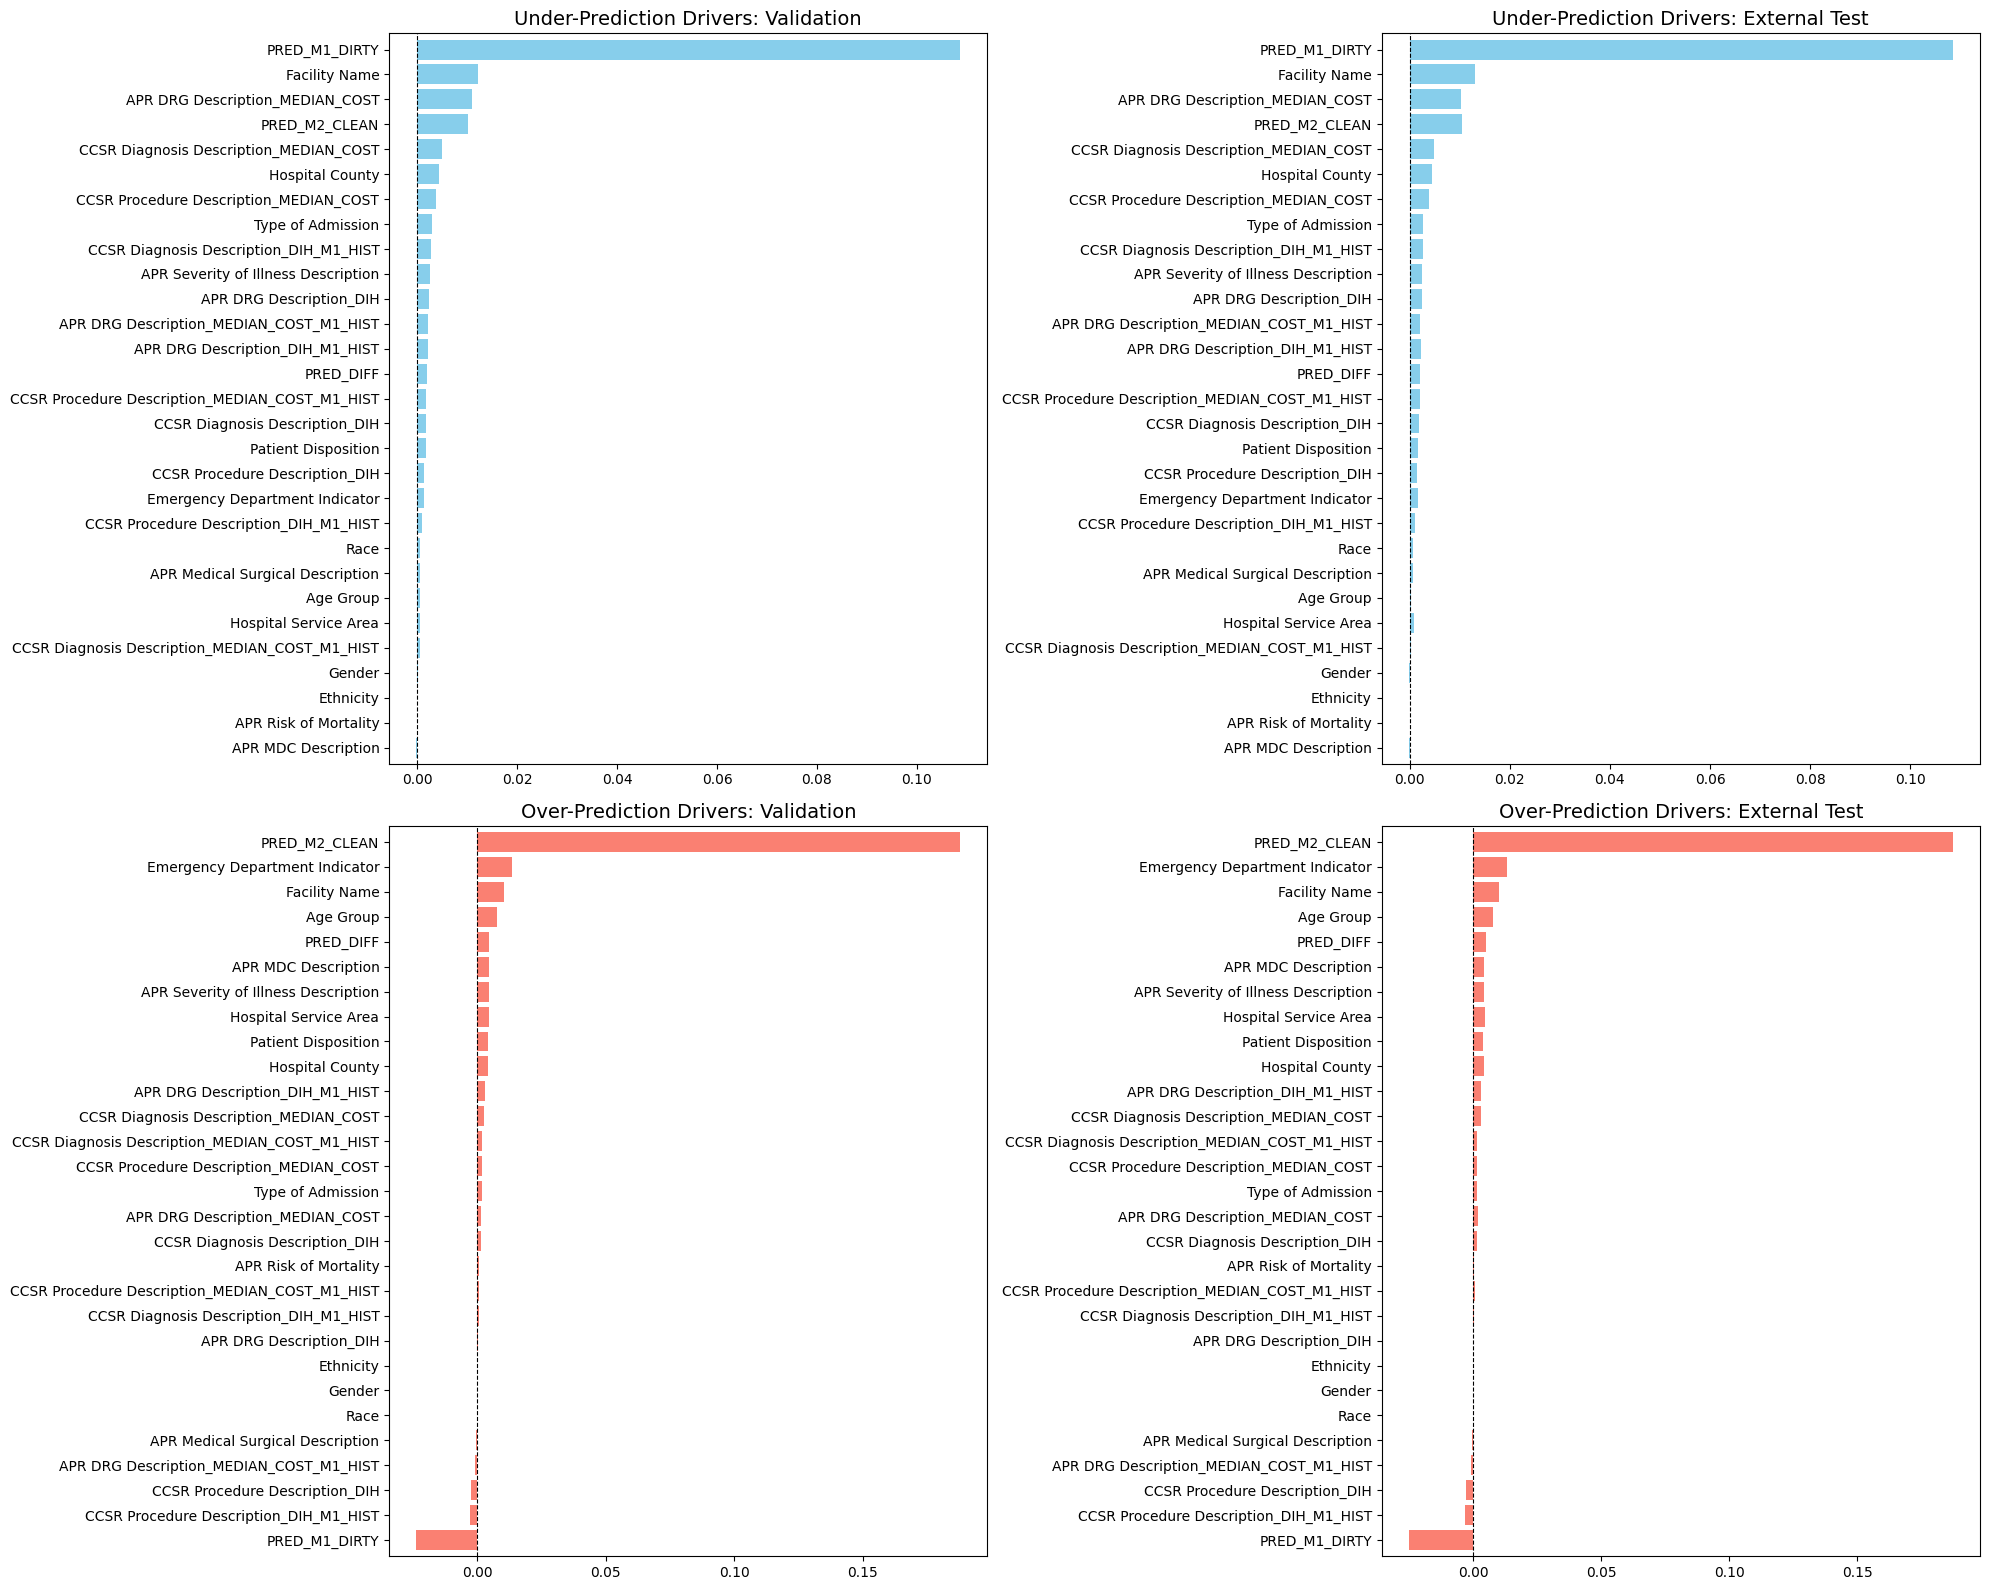

In [19]:
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# =========================================================
# 4. HYBRID FEATURE IMPORTANCE ANALYSIS (DUAL MODELS)
# =========================================================
print("Calculating Feature Importance for Dual Risk Classifiers...")

X_val_hybrid, _ = create_hybrid_features(X_test, pipeline, pipeline_v2)
X_test_hybrid, _ = create_hybrid_features(X_test_final, pipeline, pipeline_v2)

def get_importances(clf, X, y):
    result = permutation_importance(
        clf, X, y, n_repeats=5, random_state=42, n_jobs=-1, scoring='f1'
    )
    return pd.Series(result.importances_mean, index=X.columns)

print(" - Computing for Under-Prediction Model...")
imp_val_under = get_importances(risk_clf_under, X_val_hybrid, val_u_true)
imp_test_under = get_importances(risk_clf_under, X_test_hybrid, ext_u_true)

print(" - Computing for Over-Prediction Model...")
imp_val_over = get_importances(risk_clf_over, X_val_hybrid, val_o_true)
imp_test_over = get_importances(risk_clf_over, X_test_hybrid, ext_o_true)

# --- Plotting Logic (2x2 Grid) ---
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(20, 16))

def plot_imp(series_val, series_test, ax_val, ax_test, title_prefix, color):
    s_sorted = series_val.sort_values()
    s_test_aligned = series_test.reindex(s_sorted.index)
    
    s_sorted.plot(kind='barh', ax=ax_val, color=color, width=0.8)
    ax_val.set_title(f"{title_prefix}: Validation", fontsize=14)
    ax_val.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
    
    s_test_aligned.plot(kind='barh', ax=ax_test, color=color, width=0.8)
    ax_test.set_title(f"{title_prefix}: External Test", fontsize=14)
    ax_test.axvline(x=0, color='black', linestyle='--', linewidth=0.8)

# Top Row: Under-Prediction
plot_imp(imp_val_under, imp_test_under, axes[0,0], axes[0,1], "Under-Prediction Drivers", "skyblue")
# Bottom Row: Over-Prediction
plot_imp(imp_val_over, imp_test_over, axes[1,0], axes[1,1], "Over-Prediction Drivers", "salmon")

plt.tight_layout()
plt.show()


--- Analyzing PR Curves: VALIDATION SET ---


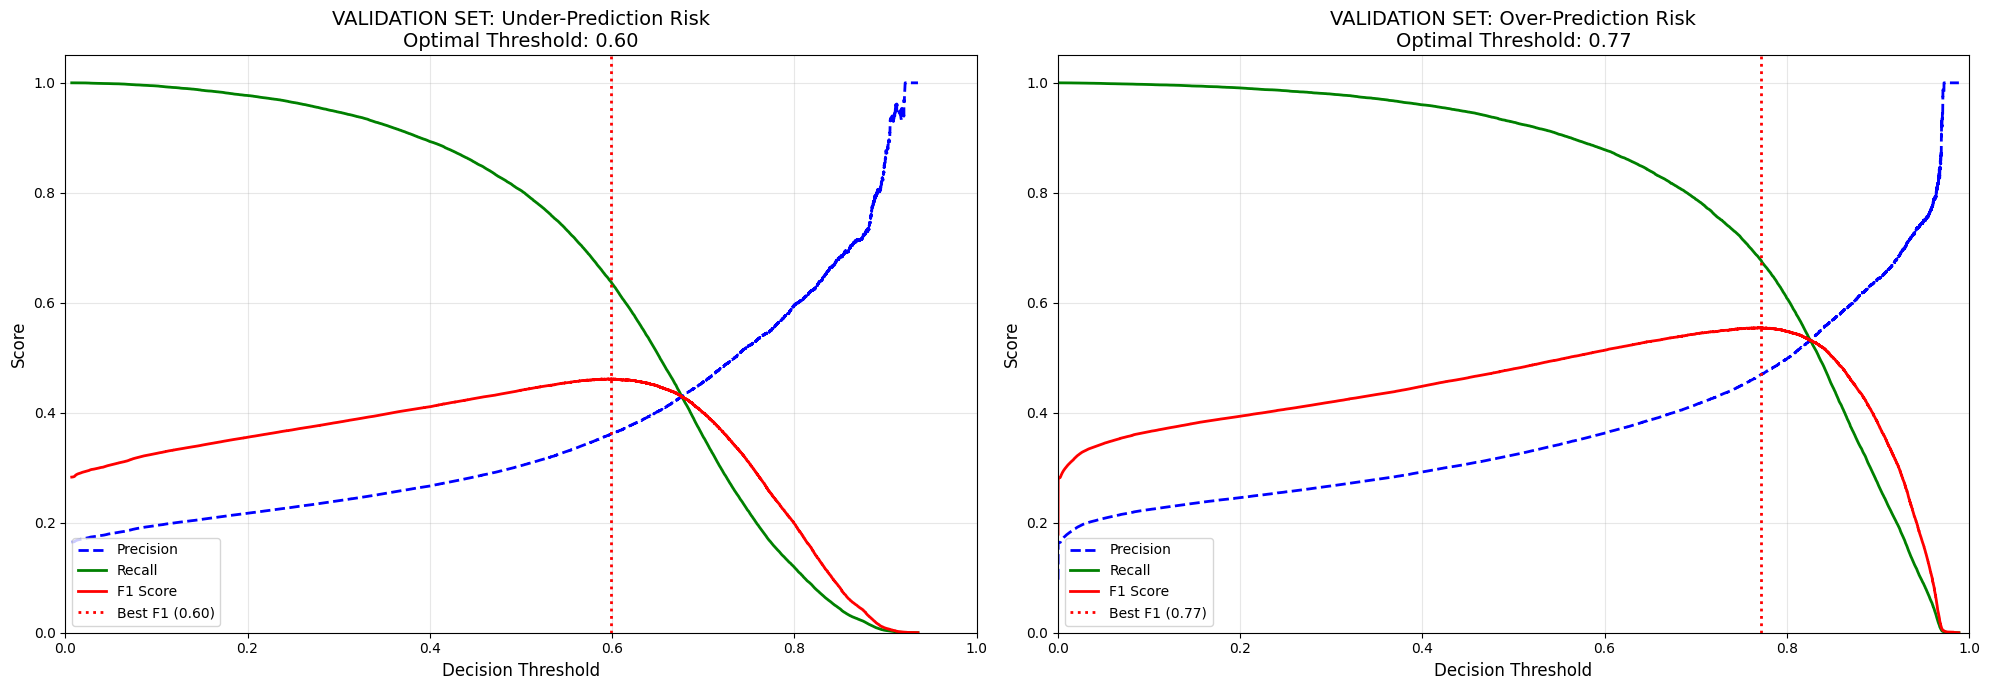


--- Analyzing PR Curves: HELD-OUT TEST SET ---


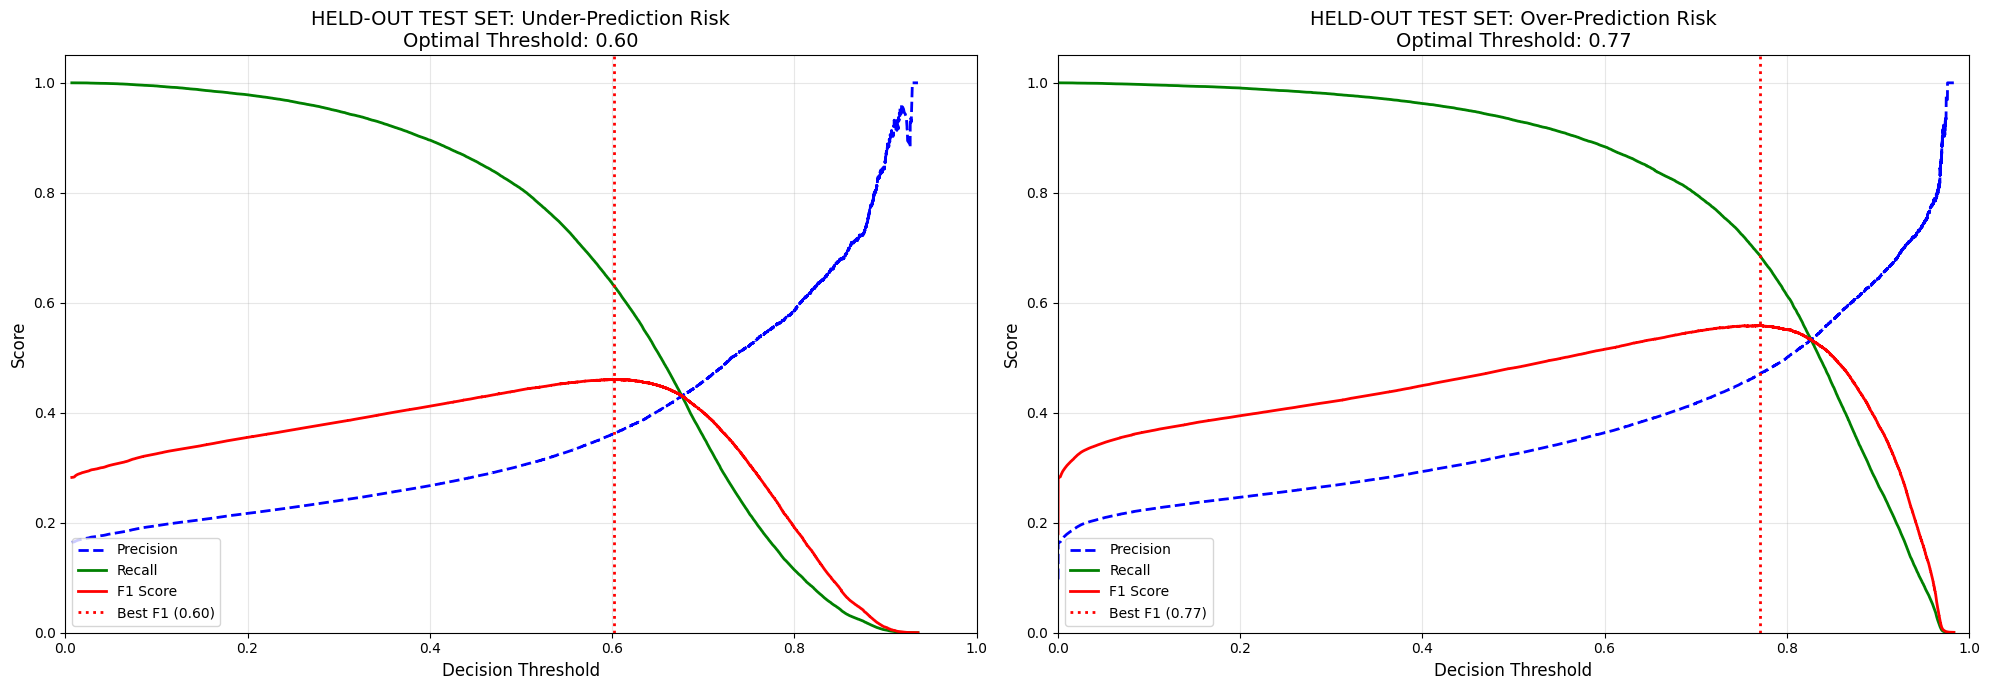

In [20]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt
import numpy as np

# =========================================================
# 5. PRECISION-RECALL CURVES (DUAL MODELS)
# =========================================================

def plot_dual_risk_thresholds(X_raw, y_true, reg_v1, reg_v2, clf_under, clf_over, dataset_name):
    print(f"\n--- Analyzing PR Curves: {dataset_name} ---")
    
    X_hybrid, y_pred_reg_v2 = create_hybrid_features(X_raw, reg_v1, reg_v2)
    residuals = y_true - y_pred_reg_v2
    
    # Ground Truths
    y_true_under = (residuals >= RISK_UNDER_LIMIT).astype(int)
    y_true_over = (residuals <= -RISK_OVER_LIMIT).astype(int)
    
    # Probabilities
    probs_under = clf_under.predict_proba(X_hybrid)[:, 1]
    probs_over = clf_over.predict_proba(X_hybrid)[:, 1]
    
    fig, axes = plt.subplots(1, 2, figsize=(20, 7))
    
    def plot_single_pr(y_true_bin, y_probs, ax, title):
        precision, recall, thresholds = precision_recall_curve(y_true_bin, y_probs)
        epsilon = 1e-7
        f1_scores = 2 * (precision * recall) / (precision + recall + epsilon)
        
        best_idx = np.argmax(f1_scores)
        best_threshold = thresholds[best_idx] if len(thresholds) > best_idx else 0.5
        
        ax.plot(thresholds, precision[:-1], 'b--', label='Precision', linewidth=2)
        ax.plot(thresholds, recall[:-1], 'g-', label='Recall', linewidth=2)
        ax.plot(thresholds, f1_scores[:-1], 'r-', label='F1 Score', linewidth=2)
        
        ax.axvline(best_threshold, color='red', linestyle=':', linewidth=2, 
                   label=f'Best F1 ({best_threshold:.2f})')
        
        ax.set_title(f'{title}\nOptimal Threshold: {best_threshold:.2f}', fontsize=14)
        ax.set_xlabel('Decision Threshold', fontsize=12)
        ax.set_ylabel('Score', fontsize=12)
        ax.legend(loc='lower left')
        ax.grid(True, alpha=0.3)
        ax.set_xlim([0, 1])
        ax.set_ylim([0, 1.05])

    plot_single_pr(y_true_under, probs_under, axes[0], f"{dataset_name}: Under-Prediction Risk")
    plot_single_pr(y_true_over, probs_over, axes[1], f"{dataset_name}: Over-Prediction Risk")
    
    plt.tight_layout()
    plt.show()

# Execute for Validation and Test
plot_dual_risk_thresholds(X_test, y_test, pipeline, pipeline_v2, risk_clf_under, risk_clf_over, "VALIDATION SET")
plot_dual_risk_thresholds(X_test_final, y_test_final, pipeline, pipeline_v2, risk_clf_under, risk_clf_over, "HELD-OUT TEST SET")

In [24]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# =========================================================
# 6 & 7. IMPACT ANALYSIS AT DIFFERENT THRESHOLDS (DUAL)
# =========================================================

def run_dual_impact_analysis(dataset_name, X_raw, y_true, model_v1, model_v2, clf_under, clf_over, thresholds=None):
    if thresholds is None:
        # Format: (Under-Prediction Threshold, Over-Prediction Threshold)
        thresholds = [(0.70, 0.85), (0.65, 0.80), (0.60, 0.75), (0.55, 0.70), (0.50, 0.65)]
        
    X_hybrid, y_pred_v2 = create_hybrid_features(X_raw, model_v1, model_v2)
    
    probs_under = clf_under.predict_proba(X_hybrid)[:, 1]
    probs_over = clf_over.predict_proba(X_hybrid)[:, 1]

    print(f"\n{'='*100}")
    print(f"             IMPACT OF DUAL RISK FILTERING ON {dataset_name.upper()}")
    print(f"{'='*100}")
    print(f"{'Thresh (U, O)':<15} | {'Status':<10} | {'% Raksha Prime Offer':<20} | {'RMSE':<12} | {'MAE':<12} | {'R2 Score':<10}")
    print("-" * 100)

    rmse_base = np.sqrt(mean_squared_error(y_true, y_pred_v2))
    mae_base = mean_absolute_error(y_true, y_pred_v2)
    r2_base = r2_score(y_true, y_pred_v2)

    print(f"{'None':<15} | {'Baseline':<10} | {'100.0%':<20} | Rs{rmse_base:,.0f}      | Rs{mae_base:,.0f}      | {r2_base:<10.4f}")
    print("-" * 100)

    for thresh_u, thresh_o in thresholds:
        # A claim is ONLY safe if it clears BOTH specific thresholds
        safe_mask = (probs_under < thresh_u) & (probs_over < thresh_o)
        
        y_true_safe = y_true[safe_mask]
        y_pred_safe = y_pred_v2[safe_mask]
        
        n_kept = len(y_true_safe)
        pct_kept = (n_kept / len(y_true)) * 100
        
        thresh_str = f"({thresh_u:.2f}, {thresh_o:.2f})"
        
        if n_kept > 0:
            rmse = np.sqrt(mean_squared_error(y_true_safe, y_pred_safe))
            mae = mean_absolute_error(y_true_safe, y_pred_safe)
            r2 = r2_score(y_true_safe, y_pred_safe)
            print(f"{thresh_str:<15} | {'Filtered':<10} | {pct_kept:<20.1f}% | Rs{rmse:,.0f}      | Rs{mae:,.0f}      | {r2:<10.4f}")
        else:
            print(f"{thresh_str:<15} | {'Filtered':<10} | 0.0%                 | N/A          | N/A          | N/A")
    print(f"{'='*100}\n")

# Define the custom threshold pairs you want to test here
test_thresholds = [(0.70, 0.85), (0.65, 0.80), (0.60, 0.75), (0.55, 0.70), (0.50, 0.65)]

# Run on Validation and Test
run_dual_impact_analysis("VALIDATION SET", X_test, y_test, pipeline, pipeline_v2, risk_clf_under, risk_clf_over, test_thresholds)
run_dual_impact_analysis("TEST SET", X_test_final, y_test_final, pipeline, pipeline_v2, risk_clf_under, risk_clf_over, test_thresholds)

# --- DETAILED METRICS BREAKDOWN ---
eval_datasets = {"VALIDATION SET": (X_test, y_test), "EXTERNAL TEST": (X_test_final, y_test_final)}

# You can adjust these evaluation pairs as needed
eval_thresholds = [(0.70, 0.85), (0.65, 0.80), (0.60, 0.75), (0.55, 0.70), (0.50, 0.65)]

for set_name, (X_raw, y_true) in eval_datasets.items():
    print(f"\n\n{'#'*80}\n   ANALYZING: {set_name}\n{'#'*80}")
    X_hybrid, y_pred_v2 = create_hybrid_features(X_raw, pipeline, pipeline_v2)
    
    probs_under = risk_clf_under.predict_proba(X_hybrid)[:, 1]
    probs_over = risk_clf_over.predict_proba(X_hybrid)[:, 1]
    
    for thresh_u, thresh_o in eval_thresholds:
        print(f"\n>>> EVALUATING THRESHOLDS: Under={thresh_u}, Over={thresh_o} (Must clear both)")
        
        # Risky if it breaches EITHER of its respective thresholds
        is_risky = (probs_under >= thresh_u) | (probs_over >= thresh_o)
        safe_mask = ~is_risky
        
        n_total = len(y_true)
        n_removed = is_risky.sum()
        
        print(f" - Cases removed: {n_removed} ({(n_removed/n_total)*100:.2f}%)")
        print(f" - Cases for RP:  {safe_mask.sum()} ({(safe_mask.sum()/n_total)*100:.2f}%)")
        
        if safe_mask.sum() > 0:
            analyze_errors(y_true[safe_mask], y_pred_v2[safe_mask], set_name=f"{set_name} - Safe (U:{thresh_u}, O:{thresh_o})")


             IMPACT OF DUAL RISK FILTERING ON VALIDATION SET
Thresh (U, O)   | Status     | % Raksha Prime Offer | RMSE         | MAE          | R2 Score  
----------------------------------------------------------------------------------------------------
None            | Baseline   | 100.0%               | Rs117,161      | Rs35,047      | 0.4960    
----------------------------------------------------------------------------------------------------
(0.70, 0.85)    | Filtered   | 81.2                % | Rs35,320      | Rs17,878      | 0.3882    
(0.65, 0.80)    | Filtered   | 73.6                % | Rs28,657      | Rs15,307      | 0.3703    
(0.60, 0.75)    | Filtered   | 66.7                % | Rs23,720      | Rs13,442      | 0.3827    
(0.55, 0.70)    | Filtered   | 60.5                % | Rs21,247      | Rs12,073      | 0.3751    
(0.50, 0.65)    | Filtered   | 54.7                % | Rs18,944      | Rs10,897      | 0.3759    


             IMPACT OF DUAL RISK FILTERING ON TEST 

In [25]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

# =========================================================
# 9. BUFFER STRATEGY ANALYSIS (UNDER-PREDICTION ONLY)
# =========================================================

def evaluate_buffer_strategy_under_only(dataset_name, X_raw, y_true, model_v2, clf_under, clf_over, decision_thresholds=(0.60, 0.75)):
    """
    Evaluates applying a financial buffer only to claims that clear BOTH risk thresholds.
    The buffer size is scaled solely by the probability of under-prediction.
    """
    # 1. Configuration
    thresh_u, thresh_o = decision_thresholds
    BUFFERS = [0, 2000, 5000, 7500, 10000, 15000] 
    
    print(f"\n{'='*85}")
    print(f"   BUFFER STRATEGY ANALYSIS: {dataset_name}")
    print(f"   (Auto-Approve Thresholds - Under: {thresh_u}, Over: {thresh_o})")
    print(f"   (Buffer applied ONLY to Under-Prediction Probabilities)")
    print(f"{'='*85}")
    
    # 2. Get Raw Predictions & Probabilities
    X_hybrid, y_pred_raw = create_hybrid_features(X_raw, pipeline, model_v2)
    probs_under = clf_under.predict_proba(X_hybrid)[:, 1]
    probs_over = clf_over.predict_proba(X_hybrid)[:, 1]
    
    # 3. Filter for Auto-Approved Only (Must clear BOTH thresholds)
    mask_safe = (probs_under < thresh_u) & (probs_over < thresh_o)
    
    if mask_safe.sum() == 0:
        print("WARNING: No claims were Auto-Approved at these thresholds.")
        return

    y_safe_actual = y_true[mask_safe]
    y_safe_pred_raw = y_pred_raw[mask_safe]
    
    # Extract ONLY the under-prediction probabilities for the safe subset
    y_safe_probs_under = probs_under[mask_safe]
    
    n_safe = len(y_safe_actual)
    
    # 4. Calculate Original Status (Buffer = 0) for Flip Tracking
    resid_orig = y_safe_pred_raw - y_safe_actual
    was_under = resid_orig < 0
    
    print(f"\nAnalyzing {n_safe} Auto-Approved Claims ({(n_safe/len(y_true)):.1%} of total)...")

    # 5. Iterate Buffers
    for buf in BUFFERS:
        print(f"\n{'>'*10} EVALUATING BUFFER MAX: Rs{buf} {'<'*10}")
        
        # A. Apply Buffer Logic (Padding scaled ONLY by under-prediction risk)
        padding = y_safe_probs_under * buf
        y_safe_pred_adj = y_safe_pred_raw + padding
        
        # B. Calculate Residuals (Pred - Actual)
        # Positive = Over-Paid, Negative = Under-Paid
        residuals = y_safe_pred_adj - y_safe_actual
        
        # C. Overall Metrics
        mae = mean_absolute_error(y_safe_actual, y_safe_pred_adj)
        rmse = np.sqrt(mean_squared_error(y_safe_actual, y_safe_pred_adj))
        
        # D. Split Analysis
        # Under-Predictions (We paid LESS than needed)
        under_mask = residuals < 0
        n_under = under_mask.sum()
        avg_under = abs(residuals[under_mask]).mean() if n_under > 0 else 0
        
        # Over-Predictions (We paid MORE than needed)
        over_mask = residuals > 0
        n_over = over_mask.sum()
        avg_over = residuals[over_mask].mean() if n_over > 0 else 0
        
        # E. Flip Analysis (The "Cost" of the Buffer)
        # Count cases that were Under-Predicted originally (at Rs0) but are now Over-Predicted
        is_flipped = (was_under) & (over_mask)
        n_flipped = is_flipped.sum()
        
        # --- PRINT DETAILED REPORT ---
        print(f"{'Metric':<25} | {'Value':<15} | {'Notes'}")
        print("-" * 70)
        print(f"{'Overall MAE':<25} | Rs{mae:<14,.0f} | (Global Error)")
        print(f"{'Overall RMSE':<25} | Rs{rmse:<14,.0f} | (Penalty for large errors)")
        print("-" * 70)
        
        # Under-Prediction Section
        pct_under = (n_under / n_safe) * 100
        print(f"{'UNDER-PREDICTIONS':<25} | {n_under:<6} ({pct_under:<4.1f}%) | Avg Deficit: Rs{avg_under:,.0f}")
        
        # Over-Prediction Section
        pct_over = (n_over / n_safe) * 100
        print(f"{'OVER-PREDICTIONS':<25} | {n_over:<6} ({pct_over:<4.1f}%) | Avg Excess:  Rs{avg_over:,.0f}")
        
        # Flip Section
        if buf > 0:
            print("-" * 70)
            print(f"{'FLIPPED CASES':<25} | {n_flipped:<14} | (Saved from Underpred -> Now Overpred)")
        print("=" * 70)

# --- EXECUTION ---
# You can easily adjust the target tuple here based on what looked best in Block 6/7
target_thresholds = (0.60, 0.75)

evaluate_buffer_strategy_under_only(
    "INTERNAL VALIDATION", 
    X_test, 
    y_test, 
    pipeline_v2, 
    risk_clf_under, 
    risk_clf_over,
    decision_thresholds=target_thresholds
)

evaluate_buffer_strategy_under_only(
    "EXTERNAL TEST SET", 
    X_test_final, 
    y_test_final, 
    pipeline_v2, 
    risk_clf_under, 
    risk_clf_over,
    decision_thresholds=target_thresholds
)


   BUFFER STRATEGY ANALYSIS: INTERNAL VALIDATION
   (Auto-Approve Thresholds - Under: 0.6, Over: 0.75)
   (Buffer applied ONLY to Under-Prediction Probabilities)

Analyzing 224554 Auto-Approved Claims (66.7% of total)...

>>>>>>>>>> EVALUATING BUFFER MAX: Rs0 <<<<<<<<<<
Metric                    | Value           | Notes
----------------------------------------------------------------------
Overall MAE               | Rs13,442         | (Global Error)
Overall RMSE              | Rs23,720         | (Penalty for large errors)
----------------------------------------------------------------------
UNDER-PREDICTIONS         | 93123  (41.5%) | Avg Deficit: Rs17,230
OVER-PREDICTIONS          | 131431 (58.5%) | Avg Excess:  Rs10,757

>>>>>>>>>> EVALUATING BUFFER MAX: Rs2000 <<<<<<<<<<
Metric                    | Value           | Notes
----------------------------------------------------------------------
Overall MAE               | Rs13,532         | (Global Error)
Overall RMSE              

In [26]:
# =========================================================
# 8. SAVE MODELS TO DISK
# =========================================================
from joblib import dump

print("\nSaving models to disk...")

# 1. Save Model V1 (The History/Dirty Model)
#    Needed to generate the 'Dirty' features for the classifier
dump(pipeline, 'models_new/charge_prediction_regressor_v1_history.joblib')
print("✅ Regressor V1 (History) saved.")

# 2. Save Model V2 (The Specialist/Clean Model)
#    This is the model used for final pricing of auto-approved claims
dump(pipeline_v2, 'models_new/charge_prediction_regressor_v2_specialist.joblib')
print("✅ Regressor V2 (Specialist) saved.")


# 3. Save the Risk Classifier (Under)
dump(risk_clf_under, 'models_new/charge_prediction_risk_classifier_under.joblib')
print("✅ Risk Classifier (Under) saved.")

# 4. Save the Risk Classifier (Over)
dump(risk_clf_over, 'models_new/charge_prediction_risk_classifier_over.joblib')
print("✅ Risk Classifier (Over) saved.")



Saving models to disk...
✅ Regressor V1 (History) saved.
✅ Regressor V2 (Specialist) saved.
✅ Risk Classifier (Under) saved.
✅ Risk Classifier (Over) saved.
